# Ballon d’Or — exploration des données

Cette première analyse décrit la couverture, les manques, les postes, le déséquilibre
et les historiques. Elle n'entraîne aucun modèle. Les données sont réelles et
proviennent du snapshot référencé dans `data/README.md` ; aucun exemple fictif
n'est mélangé au dataset.

**Reproduction :** depuis le dépôt, exécuter `python src/prepare_data.py`, puis ouvrir
ce notebook avec le noyau `.venv` et exécuter toutes les cellules, ou utiliser
`python src/run_exploration.py`. Voir `docs/passation_donnees.md`.

Le test 2022–2025 est réservé à l'évaluation finale. Ses caractéristiques
structurelles sont décrites pour identifier les problèmes de couverture ; les
comparaisons avec la cible ci-dessous sont limitées à l'entraînement.


In [1]:
from pathlib import Path
import hashlib
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

%matplotlib inline

# Compatible avec une exécution depuis la racine ou le dossier notebooks.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'src/prepare_data.py').is_file() and (p / 'data/raw/provenance.json').is_file())
processed = ROOT / 'data/processed'
raw = pd.read_csv(ROOT / 'data/raw/ballon_dor_all_years.csv')
df = pd.read_csv(processed / 'ballon_or.csv')
schema = json.loads((processed / 'features.json').read_text(encoding='utf-8'))
report = json.loads((processed / 'quality_report.json').read_text(encoding='utf-8'))
provenance = json.loads((ROOT / 'data/raw/provenance.json').read_text(encoding='utf-8'))
assert hashlib.sha256((ROOT / 'data/raw/ballon_dor_all_years.csv').read_bytes()).hexdigest() == provenance['sha256']
assert len(df) == report['output_rows']
assert not df.duplicated(['edition', 'player_id']).any()
assert df.groupby('edition')['winner'].sum().eq(1).all()
assert (df['history_last_edition'].dropna() < df.loc[df['history_last_edition'].notna(), 'edition']).all()
assert set(schema['numeric_features']).isdisjoint({'winner', 'rank', 'points', 'percent', 'edition', 'position'})
plt.rcParams.update({'figure.figsize': (11, 4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
print('Python :', sys.version.split()[0], '| pandas :', pd.__version__)
print(f"Brut : {len(raw)} lignes / {raw['year'].nunique()} éditions")
print(f"Traité : {len(df)} lignes / {df['edition'].nunique()} éditions")
display(df.loc[df['split'].eq('train')].head(5))


Python : 3.13.15 | pandas : 3.0.6
Brut : 2095 lignes / 69 éditions
Traité : 984 lignes / 30 éditions


,edition,player_id,player,club,nationality,position,previous_appearances,previous_top3,previous_wins,previous_best_rank,previous_last_rank,years_since_previous,appeared_previous_edition,has_history,history_last_edition,winner,split
0,1995,alan-shearer,Alan Shearer,Blackburn Rovers,England,Unknown,0,0,0,NaN,NaN,NaN,0,0,NaN,0,train
1,1995,alessandro-del-piero,Alessandro Del Piero,Juventus,Italy,Unknown,0,0,0,NaN,NaN,NaN,0,0,NaN,0,train
2,1995,andreas-moller,Andreas Möller,Borussia Dortmund,Germany,Unknown,3,0,0,11.0,24.0,1.0,1,1,1994.0,0,train
3,1995,bebeto,Bebeto,Deportivo La Coruña,Brazil,Unknown,0,0,0,NaN,NaN,NaN,0,0,NaN,0,train
4,1995,davor-suker,Davor Šuker,Sevilla,Croatia,Unknown,0,0,0,NaN,NaN,NaN,0,0,NaN,0,train


## 1. Couverture et séparation chronologique

Les éditions absentes et les variations d'effectifs ne doivent pas être interprétées
comme une variation du nombre de footballeurs éligibles. La source présente des
tables de résultats aux formats variables. 2020 est annulé, pas une édition avec
zéro gagnant. Les données antérieures à 1995 servent à initialiser les historiques.


,lignes,editions,gagnants
split,,,
train,714,21,21
validation,150,5,5
test,120,4,4


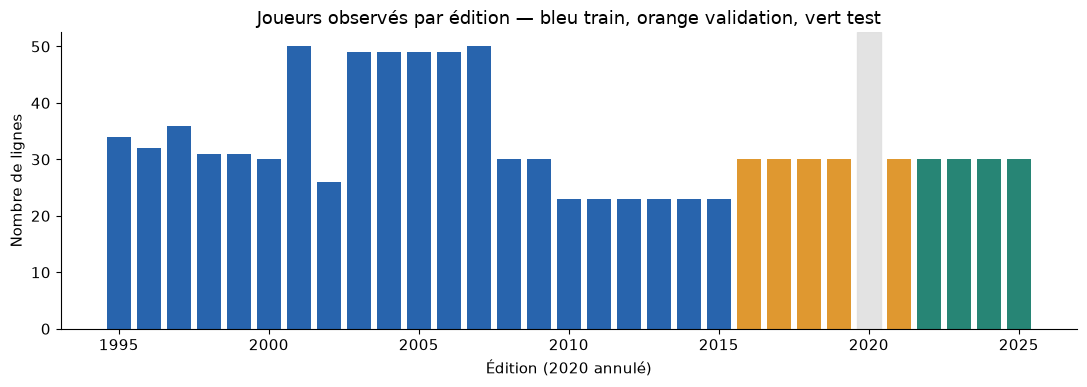

In [2]:
coverage = df.groupby('edition').agg(candidats=('player_id', 'size'), gagnants=('winner', 'sum'))
split_order = ['train', 'validation', 'test']
display(df.groupby('split').agg(lignes=('player_id', 'size'), editions=('edition', 'nunique'),
                               gagnants=('winner', 'sum')).reindex(split_order))
colors = df.groupby('edition')['split'].first().map({'train':'#2864ad', 'validation':'#df9830', 'test':'#278575'})
fig, ax = plt.subplots()
ax.bar(coverage.index, coverage['candidats'], color=colors)
ax.axvspan(2019.6, 2020.4, color='#dddddd', alpha=.8)
ax.set(title='Joueurs observés par édition — bleu train, orange validation, vert test',
       xlabel='Édition (2020 annulé)', ylabel='Nombre de lignes')
ax.set_xticks([1995, 2000, 2005, 2010, 2015, 2020, 2025])
plt.tight_layout()
plt.show()


**Observation :** les effectifs passent notamment de 50 lignes en 2001/2007 à
23 pendant la période 2010–2015. Cela décrit la source, sans prouver une cause
sportive. L'évaluation doit agréger les éditions avec le même poids, plutôt que
favoriser les années ayant davantage de lignes.


## 2. Valeurs manquantes et identités

Un `Unknown` reste une information manquante, même s'il n'est pas codé en NaN.
Les historiques vides correspondent à une première apparition **observée**.
Ils ne signifient pas une absence de carrière sportive.


,manques_brut
position,1975
nationality,150
points,146
percent,31
club,0
player,0
rank,0
year,0


,manques_traite_incluant_Unknown
nationality,150
position,864
previous_best_rank,375
previous_last_rank,375
years_since_previous,375
history_last_edition,375


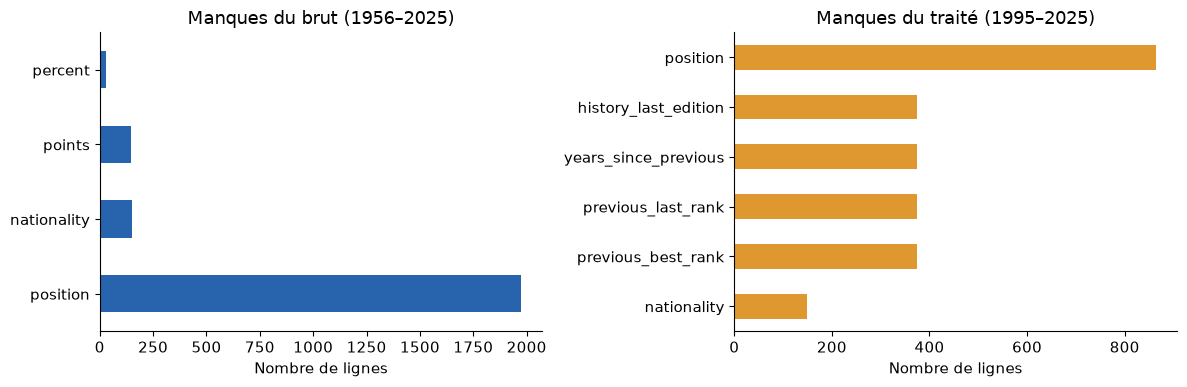

Identifiants distincts : 398
Lignes sans historique : 375


In [3]:
raw_missing = raw.isna().sum().sort_values(ascending=False)
missing = df.isna().sum()
for col in ['club', 'nationality', 'position']:
    missing[col] += df[col].eq('Unknown').sum()
display(pd.DataFrame({'manques_brut': raw_missing}))
display(pd.DataFrame({'manques_traite_incluant_Unknown': missing[missing.gt(0)]}))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
raw_missing[raw_missing.gt(0)].plot.barh(ax=axes[0], color='#2864ad')
axes[0].set(title='Manques du brut (1956–2025)', xlabel='Nombre de lignes')
missing[missing.gt(0)].sort_values().plot.barh(ax=axes[1], color='#df9830')
axes[1].set(title='Manques du traité (1995–2025)', xlabel='Nombre de lignes')
plt.tight_layout()
plt.show()
print('Identifiants distincts :', df['player_id'].nunique())
print('Lignes sans historique :', int(df['has_history'].eq(0).sum()))


**Observation :** 864 des 984 postes sont inconnus. Les 150 nationalités
manquantes concernent 2016–2021. Pour 375 lignes, aucun historique n'est observé.
On ne doit pas combler ces absences avec des informations publiées plus tard.
Les deux Luis Suárez sont séparés ; la variante d'accent de Vinícius Júnior partage
un identifiant. Les autres rapprochements restent une limite à auditer.


## 3. Répartition des postes et rupture de couverture

Le poste est renseigné uniquement en 2022–2025. Sa répartition connue décrit
donc ces quatre éditions et ne représente pas les trente éditions. Le poste est
exclu de la liste des variables d'entraînement.


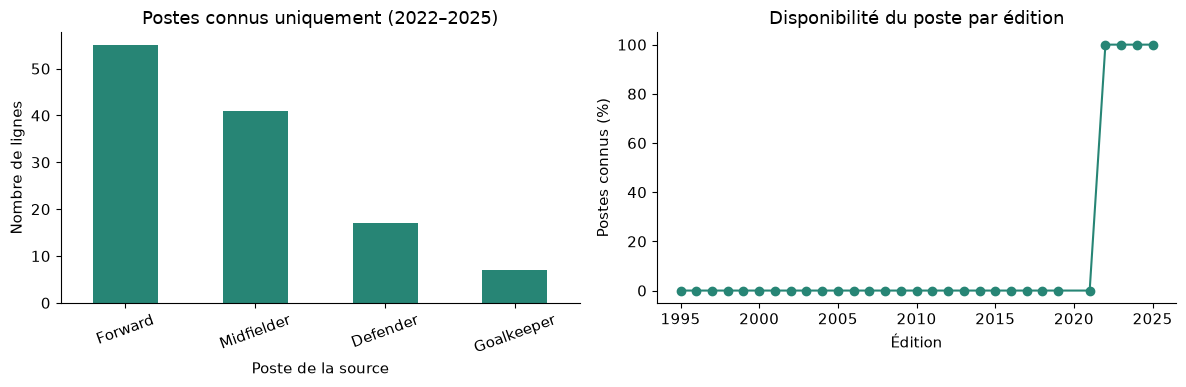

,lignes
position,
Forward,55
Midfielder,41
Defender,17
Goalkeeper,7


In [4]:
known_positions = df.loc[df['position'].ne('Unknown'), 'position'].value_counts()
position_coverage = df.assign(known=df['position'].ne('Unknown')).groupby('edition')['known'].mean() * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
known_positions.plot.bar(ax=axes[0], color='#278575', rot=20)
axes[0].set(title='Postes connus uniquement (2022–2025)', ylabel='Nombre de lignes')
axes[0].set_xlabel('Poste de la source')
axes[1].plot(position_coverage.index, position_coverage, marker='o', color='#278575')
axes[1].set(title='Disponibilité du poste par édition', xlabel='Édition', ylabel='Postes connus (%)', ylim=(-5, 105))
plt.tight_layout()
plt.show()
display(known_positions.to_frame('lignes'))


## 4. Déséquilibre gagnants / autres joueurs

Il y a un seul gagnant par édition. Une accuracy par ligne peut sembler excellente
pour un modèle qui ne désigne jamais de gagnant. Notre objectif est le classement
du gagnant parmi les candidats de chaque édition.


Gagnants : 30 / 984 (3.05 %)
Accuracy d'une réponse toujours non-gagnant : 96.95 %
Espérance aléatoire par édition : top 1 = 3.25 %, top 3 = 9.74 %


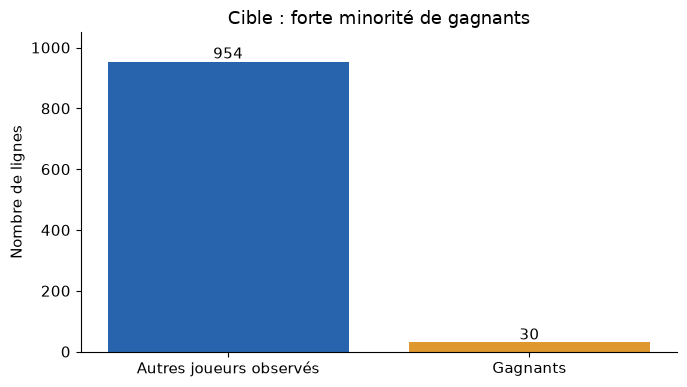

In [5]:
class_counts = df['winner'].value_counts().reindex([0, 1])
majority_accuracy = df['winner'].eq(0).mean()
print(f"Gagnants : {int(class_counts[1])} / {len(df)} ({100 * df['winner'].mean():.2f} %)")
print(f"Accuracy d'une réponse toujours non-gagnant : {100 * majority_accuracy:.2f} %")
random_top1 = (1 / coverage['candidats']).mean()
random_top3 = (3 / coverage['candidats']).clip(upper=1).mean()
print(f"Espérance aléatoire par édition : top 1 = {100 * random_top1:.2f} %, top 3 = {100 * random_top3:.2f} %")
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Autres joueurs observés', 'Gagnants'], class_counts, color=['#2864ad', '#df9830'])
for i, count in enumerate(class_counts):
    ax.text(i, count + 10, str(count), ha='center')
ax.set(title='Cible : forte minorité de gagnants', ylabel='Nombre de lignes', ylim=(0, 1050))
plt.tight_layout()
plt.show()


**Interprétation :** ces références aléatoires sont des espérances calculées,
pas les résultats d'un modèle entraîné. Elles tiennent compte des effectifs par
édition. Le top 1 et le top 3 par édition seront les critères principaux.


## 5. Tendances des historiques et relation à la cible sur le train

Les historiques mesurent la reconnaissance passée dans la source. Ils ne mesurent
ni les buts de la saison ni le mérite sportif. La comparaison gagnants/autres
est limitée à 1995–2015 ; elle ne sert pas à examiner les résultats du test.


previous_appearances        previous_top3        previous_wins       
                       mean median          mean median          mean median
winner                                                                      
0                  1.852814    1.0      0.271284    0.0      0.082251    0.0
1                  3.857143    3.0      2.000000    1.0      0.666667    0.0

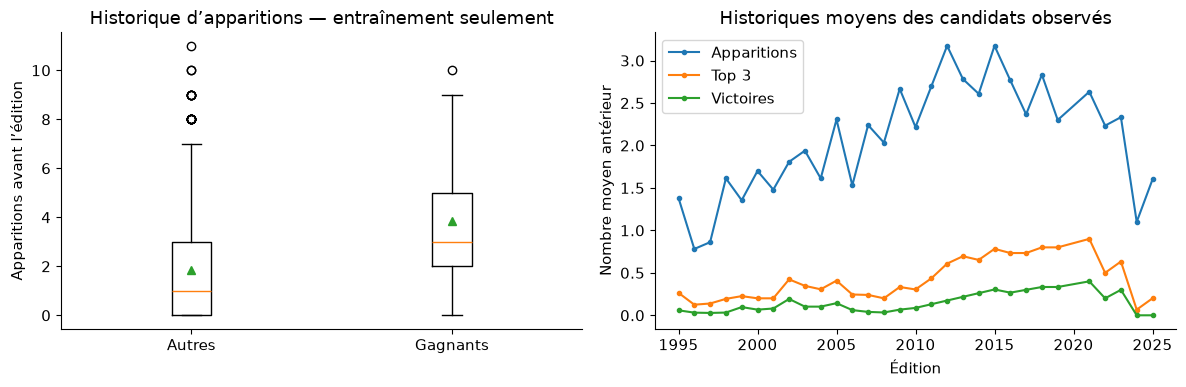

In [6]:
train = df.loc[df['split'].eq('train')].copy()
display(train.groupby('winner')[['previous_appearances', 'previous_top3', 'previous_wins']].agg(['mean', 'median']))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
samples = [train.loc[train['winner'].eq(label), 'previous_appearances'] for label in [0, 1]]
axes[0].boxplot(samples, tick_labels=['Autres', 'Gagnants'], showmeans=True)
axes[0].set(title='Historique d’apparitions — entraînement seulement', ylabel='Apparitions avant l’édition')
trend = df.groupby('edition')[['previous_appearances', 'previous_top3', 'previous_wins']].mean()
trend.plot(ax=axes[1], marker='.', linewidth=1.5)
axes[1].set(title='Historiques moyens des candidats observés', xlabel='Édition', ylabel='Nombre moyen antérieur')
axes[1].legend(['Apparitions', 'Top 3', 'Victoires'])
plt.tight_layout()
plt.show()


**Hypothèse à tester :** un historique de reconnaissance peut aider à classer
les candidats. Une différence descriptive ne prouve pas qu'il cause une victoire
et ne garantit pas la généralisation. Les lignes d'un même joueur sont dépendantes,
les périodes changent et les nouveaux joueurs peuvent avoir un historique vide.


## 6. Contrat de passage aux modèles

- Charger `ballon_or.csv` et sélectionner uniquement les huit colonnes de
  `features.json["numeric_features"]` pour les entrées.
- Conserver `edition` pour grouper l'évaluation, `player_id` pour identifier les
  candidats, `winner` pour la cible et `split` pour le découpage fixé.
- Ajuster le prétraitement sur le train ; imputer les historiques nullables dans
  ce pipeline, jamais en lisant les années de validation/test.
- Choisir les paramètres sans consulter le test ; publier ensuite le top 1,
  top 3 et le résultat de chaque édition de test.
- Les historiques de résultats passés sont disponibles à la prévision de chaque
  année ; cela ne correspond pas à prédire plusieurs années futures à une seule date.
- Documenter le biais des candidats observés et l'absence de statistiques sportives.

**Bilan :** une base reproductible est disponible, mais elle permet d'abord une
expérience sur l'historique de reconnaissance. Aucun résultat prédictif ne peut
être annoncé avant l'entraînement et l'évaluation par le binôme.


In [7]:
assert df.groupby('edition')['split'].nunique().eq(1).all()
assert df.loc[df['split'].eq('train'), 'edition'].max() < df.loc[df['split'].eq('validation'), 'edition'].min()
assert df.loc[df['split'].eq('validation'), 'edition'].max() < df.loc[df['split'].eq('test'), 'edition'].min()
assert schema['categorical_features'] == []
print('Contrôles exploration OK : groupes séparés, cible valide et entrées autorisées explicites.')


Contrôles exploration OK : groupes séparés, cible valide et entrées autorisées explicites.
